In [7]:
import sys
import pandas as pd
sys.path.append("../src")

import data_loader

In [ ]:
products = data_loader.load_products()
customers = data_loader.load_customers()
orders = data_loader.load_orders()
order_items = data_loader.load_order_items()
sales = data_loader.load_sales()
inventory = data_loader.load_inventory()
web_traffic = data_loader.load_web_traffic()
returns = data_loader.load_returns()
geography = data_loader.load_geography()
payments = data_loader.load_payments()

# Q1 - C?

In [9]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [10]:
inter_days = orders.groupby("customer_id").agg(
    counts=("order_id", "count"),
    min_date=("order_date", "min"),
    max_date=("order_date", "max"),
    inter_days=("order_date", lambda row: row.sort_values().diff().iloc[1:])
)
exploded = inter_days[inter_days["counts"] > 1].explode("inter_days")

Median inter-arrival days: 144


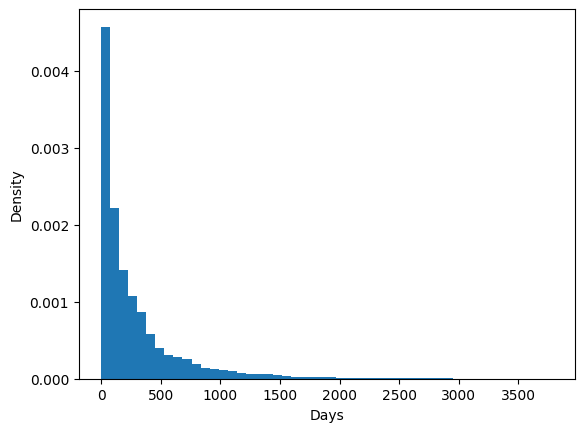

In [12]:
exploded["inter_days"].dt.days.plot.hist(
    bins=50,
    density=True,
    xlabel="Days",
    ylabel="Density"
)

print(f"Median inter-arrival days: {exploded['inter_days'].median().days}")

# Q2 - D

In [13]:
products["ros"] = (products["price"] - products["cogs"]) / products["price"]

In [14]:
sums = products.groupby("segment").agg(
    price=("price", "sum"),
    cogs=("cogs", "sum")
)
ros = ((sums["price"] - sums["cogs"]) / sums["price"]).sort_values(ascending=False)

Maximum ROS segment: Standard


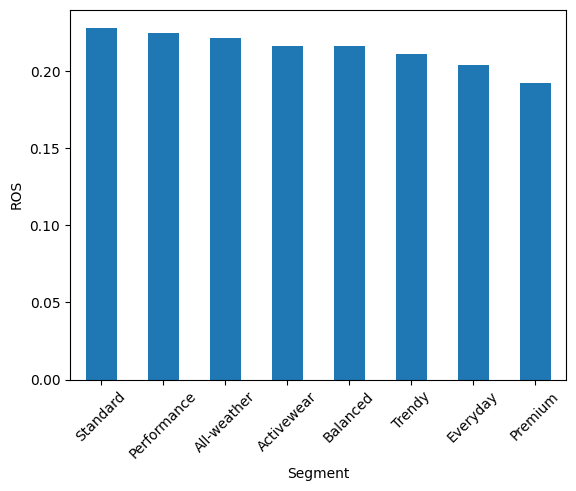

In [16]:
ros.plot.bar(
    rot=45,
    xlabel="Segment",
    ylabel="ROS"
)

print(f"Maximum ROS segment: {ros.index[0]}")

# Q3 - B

In [19]:
returned_products = returns.rename(columns=lambda i: f"returns.{i}").merge(
    products.rename(columns=lambda x: f"products.{x}"),
    "left",
    left_on="returns.product_id",
    right_on="products.product_id",
)
ranked_reason = returned_products[returned_products["products.category"] == "Streetwear"].value_counts("returns.return_reason")

Most common return reason for Streetwear: wrong_size


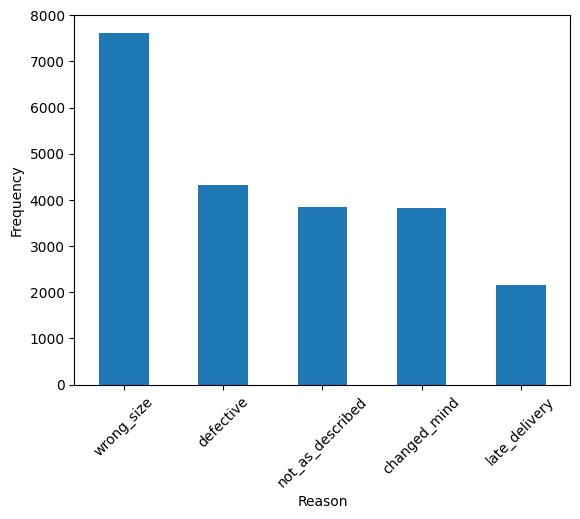

In [22]:
ranked_reason.plot.bar(
    rot=45,
    xlabel="Reason",
    ylabel="Frequency"
)

print(f"Most common return reason for Streetwear: {ranked_reason.index[0]}")

# Q4 - C

In [23]:
web_traffic["one_hit_session"] = web_traffic["bounce_rate"] * web_traffic["sessions"] 

In [24]:
avg_bounce_rates = web_traffic.groupby("traffic_source").agg(
    one_hit_session=("one_hit_session", "sum"),
    sessions=("sessions", "sum"),
)
avg_bounce_rates["avg_br"] = avg_bounce_rates["one_hit_session"] / avg_bounce_rates["sessions"]
avg_bounce_rates.sort_values("avg_br", inplace=True)

Source with lowest avg bounce rate: email_campaign


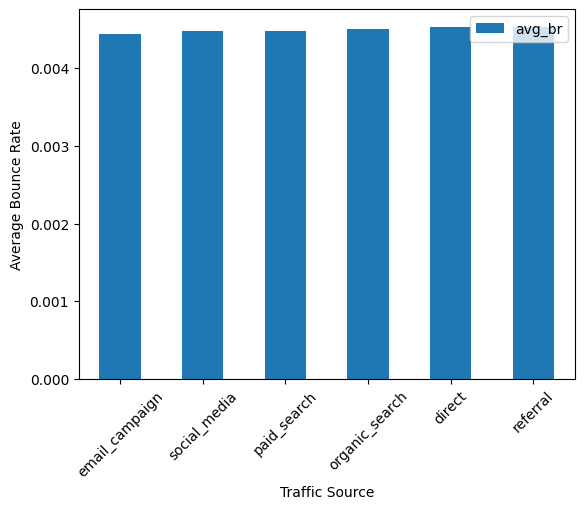

In [26]:
avg_bounce_rates.plot.bar(
    y="avg_br",
    rot=45,
    xlabel="Traffic Source",
    ylabel="Average Bounce Rate"
)

print(f"Source with lowest avg bounce rate: {avg_bounce_rates.index[0]}")

# Q5 - C

In [28]:
with_promotions = order_items["promo_id"].notna().sum()
total_orders = len(order_items)

ratio = with_promotions / total_orders

print(
    f"Percentage of orders with promotions: "
    f"{with_promotions} / {total_orders} "
    f"= {ratio:.2%}"
)

Percentage of orders with promotions: 276316 / 714669 = 38.66%


# Q6 - A

In [29]:
customers.dropna(subset=["age_group"], inplace=True)

In [30]:
orders_w_customers = orders.merge(
    customers.rename(columns=lambda i: f"customers.{i}"),
    left_on="customer_id",
    right_on="customers.customer_id"
)
groupby_age = orders_w_customers.groupby("customers.age_group").agg(
    num_orders=("order_id", "nunique"),
).merge(
    customers.value_counts("age_group"),
    "left", left_index=True, right_index=True
)
groupby_age["avg_orders"] = groupby_age["num_orders"] / groupby_age["count"]
groupby_age.sort_values("avg_orders", ascending=False, inplace=True)

Age group with highest number of orders per customer: 55+


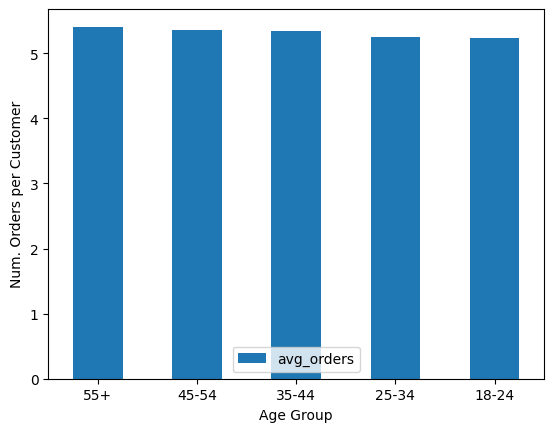

In [31]:
groupby_age.plot.bar(
    y="avg_orders",
    rot=0,
    xlabel="Age Group",
    ylabel="Num. Orders per Customer"
)

print(f"Age group with highest number of orders per customer: {groupby_age.index[0]}")

# Q7 - C?

In [33]:
geography = data_loader.load_geography()

In [34]:
orders_w_zip = orders[["order_id", "zip"]].rename(columns=lambda i: f"orders.{i}").merge(
    geography.rename(columns=lambda i: f"geography.{i}"),
    left_on="orders.zip",
    right_on="geography.zip"
)
orders_w_items = order_items.rename(columns=lambda i: f"order_items.{i}").merge(
    orders_w_zip,
    left_on="order_items.order_id",
    right_on="orders.order_id"
)
orders_w_items["revenue"] = orders_w_items["order_items.quantity"] * orders_w_items["order_items.unit_price"]

total_rev = orders_w_items.groupby("geography.region").agg(
    total_revenue=("revenue", "sum")
).sort_values("total_revenue", ascending=False)

Region with highest revenue: East


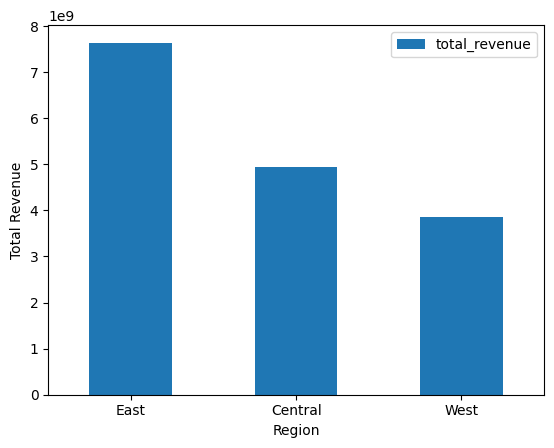

In [36]:
total_rev.plot.bar(
    y="total_revenue",
    rot=0,
    xlabel="Region",
    ylabel="Total Revenue"
)

print(f"Region with highest revenue: {total_rev.index[0]}")

# Q8 - A

Most used payment method within cancelled orders: credit_card


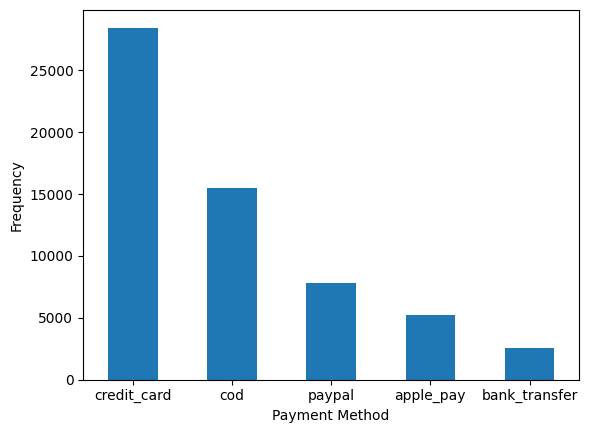

In [51]:
payment_methods = orders[orders["order_status"] == "cancelled"].value_counts("payment_method")
payment_methods.plot.bar(
    rot=0,
    xlabel="Payment Method",
    ylabel="Frequency"
)

print(f"Most used payment method within cancelled orders: {payment_methods.index[0]}")

In [50]:
# Lọc các đơn bị huỷ
cancelled_orders = orders[orders["order_status"] == "cancelled"]

# Join với bảng payments
cancelled_payments = cancelled_orders.merge(
    payments,
    on="order_id",
    how="left"
)

# Đếm phương thức thanh toán
payment_counts = cancelled_payments["payment_method_y"].value_counts()

print(payment_counts)

print(f"Most common payment method for cancelled orders: {payment_counts.index[0]}")

payment_method_y
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64
Most common payment method for cancelled orders: credit_card


# Q9 - A

In [39]:
returned_ratios = returned_products.value_counts("products.size", ascending=True) / order_items.merge(
    products.rename(columns=lambda i: f"products.{i}"),
    left_on="product_id",
    right_on="products.product_id",
).value_counts("products.size", ascending=True)

Size with highest return ratio: S


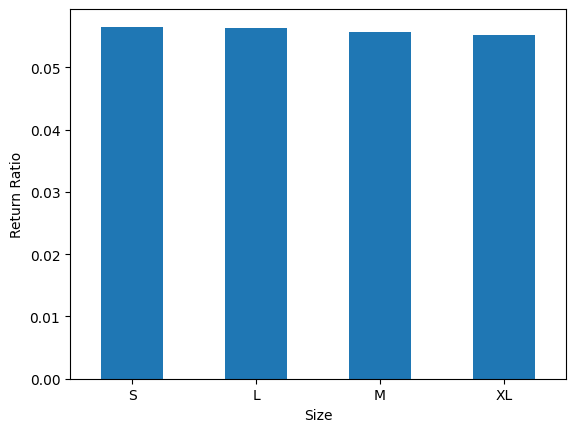

In [40]:
returned_ratios.plot.bar(
    y="return_ratio",
    rot=0,
    xlabel="Size",
    ylabel="Return Ratio"
)

print(f"Size with highest return ratio: {returned_ratios.index[0]}")

# Q10 - C

In [43]:
groupby_installments = payments.groupby("installments").agg(
    avg_payment_value=("payment_value", "mean")
).sort_values("avg_payment_value", ascending=False)

Installment with highest average payment value per order: 6


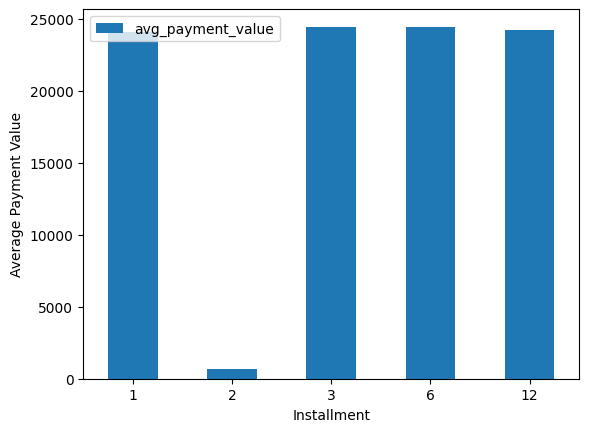

In [44]:
groupby_installments.sort_index().plot.bar(
    rot=0,
    xlabel="Installment",
    ylabel="Average Payment Value"
)

print(f"Installment with highest average payment value per order: {groupby_installments.index[0]}")